In [54]:
import pandas as pd
df= pd.read_csv('insurance_claim.csv')
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [ ]:
#Cleaning data: duplicate and missing

In [55]:
missing_values_row = df.isnull().any(axis=1)
print("Rows with missing values: ", "\n", df[missing_values_row])
#also we can print with 
#print("rows with missing values: ")
#print(data[missing_values_row])

Rows with missing values:  
     index  PatientID   age gender   bmi  bloodpressure diabetic  children  \
2       2          3   NaN   male  33.3             82      Yes         0   
3       3          4   NaN   male  33.7             80       No         0   
4       4          5   NaN   male  34.1            100       No         0   
5       5          6   NaN   male  34.4             96      Yes         0   
6       6          7   NaN   male  37.3             86      Yes         0   
13     13         14  32.0   male  27.6            100       No         0   
14     14         15  40.0   male  28.7             81      Yes         0   
15     15         16  32.0   male  30.4             86      Yes         0   

   smoker     region    claim  
2      No  southeast  1135.94  
3      No  northwest  1136.40  
4      No  northwest  1137.01  
5      No  northwest  1137.47  
6      No  northwest  1141.45  
13     No        NaN  1252.41  
14     No        NaN  1253.94  
15     No        NaN 

In [48]:
#to check duplicate:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [index, PatientID, age, gender, bmi, bloodpressure, diabetic, children, smoker, region, claim]
Index: []


In [51]:
#to remove missing value:
#df.dropna(axis=0, inplace= True)

In [42]:
#to remove duplicate value:
#df.drop_duplicates(inplace=True)

In [77]:
#relation between age, gender, disease.
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
age_claim_corr= df['age'].corr(df['claim'])
print("correlation coefficient between age and claim amount: ", age_claim_corr)
mean_claim= df.groupby('gender')['claim'].mean().reset_index()
median_claim= df.groupby('gender')['claim'].median().reset_index()
gender_stats = pd.merge(mean_claim, median_claim, on='gender', suffixes= ('_mean', '_median')) 
print("gender wise claim amount stats")
print(gender_stats)




correlation coefficient between age and claim amount:  -0.027908809752189057
gender wise claim amount stats
   gender    claim_mean  claim_median
0  female  12569.578897      9412.965
1    male  13919.790457      9333.015


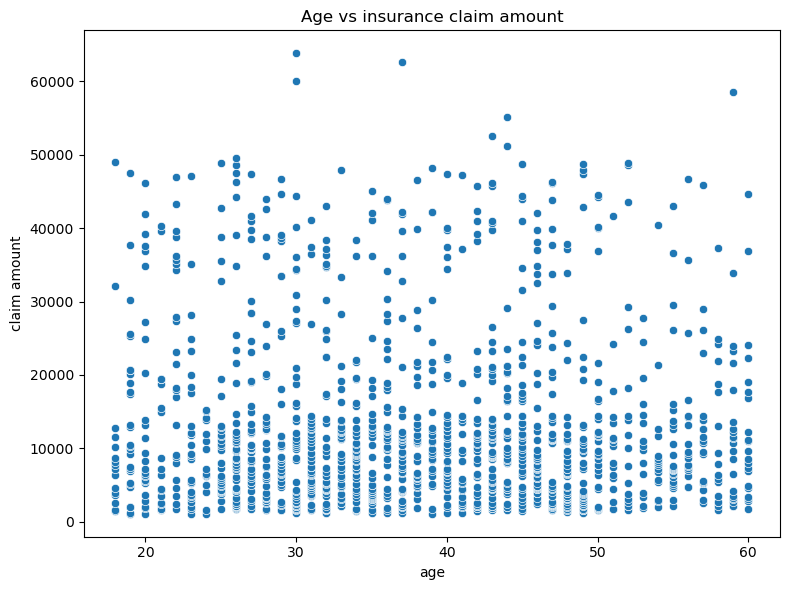

In [79]:
#scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="age", y="claim", data=df)
plt.title('Age vs insurance claim amount')
plt.xlabel("age")
plt.ylabel("claim amount")
plt.tight_layout()
plt.show()

In [2]:
#Barplot
plt.figure(figsize=(8,6))
sns.barplot(x='gender', y='claim_mean', data=gender_stats, palette= 'viridis')
plt.title("Avg claim amount by gender")
plt.xlabel('gender')
plt.ylabel("avg claim amount")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [86]:
#ch 2 #correlation between BMI with insurance claim amount 
data= pd.read_csv('insurance_claim.csv')
data.head()


,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [88]:
import matplotlib.pyplot as plt
corr_bmi_claim= data['bmi'].corr(data['claim'])
corr_bp_claim= data['bloodpressure'].corr(data['claim'])
print(f"cc bw BMI and claim amount: {corr_bmi_claim}")
print(f"cc bw BP and claim amount: {corr_bp_claim}")

cc bw BMI and claim amount: 0.19740133652071135
cc bw BP and claim amount: 0.5313409750663161


In [1]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(data['bmi'], data['claim'], alpha=0.5, color='blue')
plt.title("BMI vs Insurance claim amount")
plt.xlabel('BMI')
plt.ylabel("Claim amount")

NameError: name 'plt' is not defined

In [ ]:
plt.subplot(1,2,2)